In [73]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

In [74]:
def mid_tread_quantize(X : list, delta) -> tuple[list, list]:
    indices = np.floor(X / delta)
    qx = delta * (indices + 0.5)
    return qx, indices

def mid_tread_deindex(indices : list, delta) -> list:
    return delta * (indices + 0.5)

def mid_riser_quantize(X : list, delta) -> tuple[list, list]:
    indices = np.floor(X / delta + 0.5)
    qx = delta * indices
    return qx, indices

def mid_riser_deindex(indices : list, delta) -> list:
    return delta * indices

In [75]:
sr, data = wavfile.read("../assets/audio.wav")
data = np.array(data).transpose()[0] # 1 channel, range [-32768, 32767]
data

array([0, 0, 0, ..., 0, 0, 0], shape=(9934848,), dtype=int16)

In [76]:
values, counts = np.unique(data, return_counts=True)
pmf_x = counts / len(data)

In [77]:
H_x = - np.sum(pmf_x * np.log2(pmf_x))
print(f"Entropy of data: {H_x:.4f} bits/sample")

Entropy of data: 14.6916 bits/sample


In [78]:
desired_rate = 5.0 # bits/sample

delta = 2 ** (H_x - desired_rate)

print(' Delta: ', delta)

quantized_data, indices = mid_tread_quantize(data, delta)

values, counts = np.unique(indices, return_counts=True)
pmf_y = counts / len(indices)
H_y = - np.sum(pmf_y * np.log2(pmf_y))
print(f"Entropy of quantized data: {H_y:.4f} bits/sample")


 Delta:  826.9255588521529
Entropy of quantized data: 5.4399 bits/sample


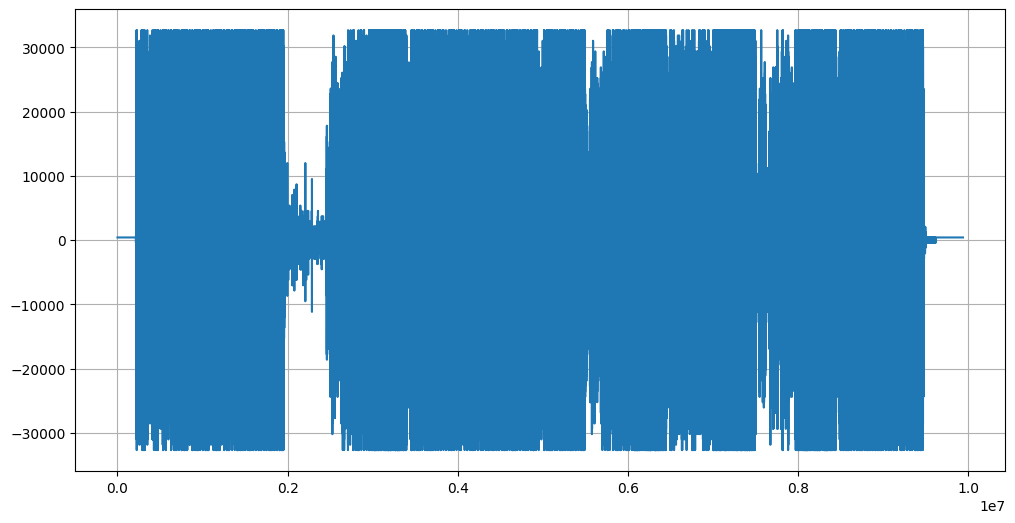

In [79]:
plt.figure(figsize=(12, 6))
plt.plot(quantized_data)
plt.grid()

In [80]:
# convert to int16 (standard WAV format)
audio_int16 = (quantized_data).astype(np.int16)

wavfile.write("output.wav", sr, audio_int16)